
#1. Capa e Instruções

##1.1. Resolução do problema SantosPackLogistics

##1.2. Autores:
- Luis Eduardo Alencar Melo
- João Pedro Coelho Barbosa

##1.3. Instruções:

- Os datasets utilizados são os disponibilizados em aula, então no bloco de importações é necessário direcionar aos datasets


#2. Introdução

##2.1. Descrição da empresa fictícia e cenário real:
A SantosPack é uma empresa de courier express que distribui caixas e encomendas.
- Cenário real: cada veículo de entrega tem limite de peso e volume. Selecionar quais
encomendas carregar para maximizar o lucro (valor de entrega), sem exceder ambos
os limites.

---
##2.2. Formulação matemática do problema.

###  **Definições**

* $n$: número total de encomendas disponíveis.

* Para cada encomenda $i \in \{1, 2, ..., n\}$:

  * $p_i$: valor (lucro) da encomenda $i$
  * $w_i$: peso da encomenda $i$
  * $v_i$: volume da encomenda $i$
  * $x_i \in \{0, 1\}$: variável binária indicando se a encomenda $i$ será incluída (1) ou não (0)

* $W$: capacidade máxima de **peso** do veículo.

* $V$: capacidade máxima de **volume** do veículo.

---

### **Função Objetivo**

Queremos **maximizar o valor total das encomendas carregadas**, **penalizando excedentes** de peso e volume:

$$
\max \left( \sum_{i=1}^{n} p_i x_i - \lambda_w \cdot \max\left(0, \sum_{i=1}^{n} w_i x_i - W \right) - \lambda_v \cdot \max\left(0, \sum_{i=1}^{n} v_i x_i - V \right) \right)
$$

---

### **Restrições (implícitas com penalidades)**

* A penalidade é aplicada **somente se houver excesso**. Portanto:

  * Excesso de peso: $\max(0, \sum w_i x_i - W)$
  * Excesso de volume: $\max(0, \sum v_i x_i - V)$

* $\lambda_w$, $\lambda_v$: coeficientes de penalidade por excesso de peso e volume, respectivamente. Devem ser calibrados (valores suficientemente grandes para desestimular soluções inválidas, mas permitir exploração no AG).

---

###  **Resumo da Formulação**

#### Variáveis:

$$
x_i \in \{0, 1\}, \quad \forall i = 1, \dots, n
$$

#### Função Objetivo (Maximizar Lucro com Penalidade):

$$
\max_{x \in \{0,1\}^n} \left[ \sum_{i=1}^{n} p_i x_i - \lambda_w \cdot \max\left(0, \sum_{i=1}^{n} w_i x_i - W \right) - \lambda_v \cdot \max\left(0, \sum_{i=1}^{n} v_i x_i - V \right) \right]
$$

---

### 💡 **Observações para Implementação Heurística**

* Representação da solução: vetor binário $x = (x_1, x_2, ..., x_n)$
* Avaliação da aptidão = valor total − penalidade
* Aplicável com:

  * **AG** (Algoritmo Genético): usar seleção, crossover e mutação.



# 3. Importação de Bibliotecas e Dados

## 3.1.  numpy, matplotlib, pandas, bibliotecas de meta-heurísticas (ex.: DEAP).

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

capacities_10 = pd.read_csv('/content/drive/MyDrive/ICEV/Computacao Bioinspirada/Atividade pratica/SantosPack Logistics/capacities_10.csv')
capacities_20 = pd.read_csv('/content/drive/MyDrive/ICEV/Computacao Bioinspirada/Atividade pratica/SantosPack Logistics/capacities_20.csv')
capacities_df = pd.read_csv('/content/drive/MyDrive/ICEV/Computacao Bioinspirada/Atividade pratica/SantosPack Logistics/capacities_40.csv')

items_10 = pd.read_csv('/content/drive/MyDrive/ICEV/Computacao Bioinspirada/Atividade pratica/SantosPack Logistics/items_10.csv')
items_20 = pd.read_csv('/content/drive/MyDrive/ICEV/Computacao Bioinspirada/Atividade pratica/SantosPack Logistics/items_20.csv')
items_df = pd.read_csv('/content/drive/MyDrive/ICEV/Computacao Bioinspirada/Atividade pratica/SantosPack Logistics/items_40.csv')

# === Parâmetros AG ===
POP_SIZE = 200
P_CROSS = 0.85
P_MUT = 0.015
MAX_GEN = 200
ELITISM = True
TOURNAMENT_K = 3
lambda_weight = 5
lambda_volume = 5

def clean_dataset(items_df, capacities_df):
    items_df[['weight', 'volume', 'profit']] = items_df[['weight', 'volume', 'profit']].astype(float)
    capacities_df['capacity_value'] = capacities_df['capacity_value'].astype(float)
    return items_df, capacities_df



# 4. Modelagem e Função-Objetivo
## 4.1. Código que calcula custo, makespan ou cobertura para uma solução dada.

In [15]:
def fitness_solution_df(x, items_df, capacities_df, lambda_weight, lambda_volume):
    """
    Calcula o fitness de uma solução para o problema.
    Inclui penalização progressiva para violações de restrições.
    """
    x = np.asarray(x, dtype=np.int8)

    weights = items_df['weight'].values.astype(np.float32)
    volumes = items_df['volume'].values.astype(np.float32)
    profits = items_df['profit'].values.astype(np.float32)

    try:
        max_weight = float(capacities_df.loc[capacities_df['capacity_type'] == 'weight', 'capacity_value'].iloc[0])
        max_volume = float(capacities_df.loc[capacities_df['capacity_type'] == 'volume', 'capacity_value'].iloc[0])
    except (IndexError, KeyError):
        raise ValueError("Capacidades de 'weight' e 'volume' não encontradas em capacities_df")

    total_profit = np.dot(profits, x)
    total_weight = np.dot(weights, x)
    total_volume = np.dot(volumes, x)

    overweight = np.maximum(0.0, total_weight - max_weight)
    overvolume = np.maximum(0.0, total_volume - max_volume)

    if overweight > 0:
        weight_penalty = lambda_weight * overweight * (1 + overweight / max_weight)
    else:
        weight_penalty = 0.0

    if overvolume > 0:
        volume_penalty = lambda_volume * overvolume * (1 + overvolume / max_volume)
    else:
        volume_penalty = 0.0

    penalty = weight_penalty + volume_penalty

    fitness = total_profit - penalty

    return float(fitness)

# 5. Implementação do Algoritmo Bioinspirado
- Classe/funções principais do AG.
- Parâmetros escolhidos (população, iterações, taxas).

In [16]:
def initialize_population(pop_size: int, n_items: int) -> np.ndarray:
    """
    Gera população inicial com vetores binários.
    """
    return np.random.randint(2, size=(pop_size, n_items))


In [17]:
def tournament_selection(population, fitnesses, k=TOURNAMENT_K):
    """
    Seleção por torneio com fitness pré-calculado.

    Args:
        population (list[list[int]]): lista de indivíduos
        fitnesses (list[float]): valores de fitness correspondentes
        k (int): número de participantes do torneio

    Returns:
        list[int]: indivíduo vencedor do torneio
    """
    participantes = []
    while len(participantes) < k:
        idx = np.random.randint(0, len(population))
        if idx not in participantes:
            participantes.append(idx)

    best_idx = participantes[0]
    best_fit = fitnesses[best_idx]
    for idx in participantes[1:]:
        if fitnesses[idx] > best_fit:
            best_idx = idx
            best_fit = fitnesses[idx]

    return population[best_idx]


In [18]:
def one_point_crossover(parent1, parent2):
    """
    Executa crossover de ponto único com probabilidade P_CROSS.

    Args:
        parent1, parent2 (list[int]): indivíduos pais

    Returns:
        tuple: dois filhos
    """
    if np.random.rand() < P_CROSS:
        point = np.random.randint(1, len(parent1))
        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
    else:
        child1, child2 = parent1.copy(), parent2.copy()
    return child1, child2


In [19]:
def bit_flip_mutation(individual):
    """
    Executa mutação bit-flip com probabilidade P_MUT por gene.

    Args:
        individual (list[int]): vetor binário

    Returns:
        list[int]: indivíduo mutado
    """
    mutated = [
        gene if np.random.rand() > P_MUT else 1 - gene
        for gene in individual
    ]
    return mutated


In [20]:
def genetic_algorithm(items_df, capacities_df, lambda_volume, lambda_weight):
    """
    ==============================================================================
    ALGORITMO GENÉTICO PARA PROBLEMA DA MOCHILA MÚLTIPLA (MKP)
    ==============================================================================
    Implementação de AG clássico com seleção por torneio, crossover de um ponto,
    mutação bit-flip e elitismo. Evolui população binária por MAX_GEN gerações
    usando função de fitness com penalização progressiva.

    Retorna: melhor solução (lista binária), melhor fitness e gráfico de evolução
    ==============================================================================
    """
    n_items = len(items_df)

    population = [list(map(int, ind)) for ind in initialize_population(POP_SIZE, n_items)]

    best_fitnesses = []
    best_individual = None
    best_score = float('-inf')

    for gen in range(MAX_GEN):
        fitnesses = [fitness_solution_df(ind, items_df, capacities_df, lambda_weight, lambda_volume) for ind in population]

        new_population = []

        if ELITISM:
            elite_index = int(np.argmax(fitnesses))
            elite = population[elite_index]
            new_population.append(elite)

        while len(new_population) < POP_SIZE:
            p1 = tournament_selection(population, fitnesses)
            p2 = tournament_selection(population, fitnesses)

            c1, c2 = one_point_crossover(p1, p2)
            c1 = bit_flip_mutation(c1)
            c2 = bit_flip_mutation(c2)

            new_population.append(c1)
            if len(new_population) < POP_SIZE:
                new_population.append(c2)

        population = new_population
        gen_best_fitness = max(fitnesses)
        gen_best_individual = population[np.argmax(fitnesses)]
        best_fitnesses.append(gen_best_fitness)

        if gen_best_fitness > best_score:
            best_score = gen_best_fitness
            best_individual = gen_best_individual

        print(f"Geração {gen+1}/{MAX_GEN} - Melhor Fitness: {gen_best_fitness}")

    # Gráfico da evolução
    plt.plot(best_fitnesses)
    plt.title("Evolução do Fitness")
    plt.xlabel("Geração")
    plt.ylabel("Melhor Fitness")
    plt.grid(True)
    plt.show()

    return best_individual, best_score


In [21]:
def avaliar_resultado(items_df, capacities_df, best_individual, lambda_weight, lambda_volume, nome_dataset="Dataset"):
    """
     ==============================================================================
     FUNÇÃO DE AVALIAÇÃO DE RESULTADOS - MKP
     ==============================================================================
     Analisa e exibe resultados detalhados da melhor solução encontrada pelo AG.
     Calcula métricas, verifica violações de restrições, lista itens incluídos/
     excluídos e identifica oportunidades de melhoria na solução.
     ==============================================================================
    """
    print(f"\n Avaliação dos Resultados - {nome_dataset}")

    selected_items_df = items_df[np.array(best_individual) == 1].copy()
    selected_items_df['index'] = selected_items_df.index


    total_weight = selected_items_df['weight'].sum()
    total_volume = selected_items_df['volume'].sum()
    total_profit = selected_items_df['profit'].sum()

    max_weight = float(capacities_df.loc[capacities_df['capacity_type'] == 'weight', 'capacity_value'].values[0])
    max_volume = float(capacities_df.loc[capacities_df['capacity_type'] == 'volume', 'capacity_value'].values[0])

    # Penalidades
    overweight = max(0, total_weight - max_weight)
    overvolume = max(0, total_volume - max_volume)
    penalty = lambda_weight * overweight + lambda_volume * overvolume
    fitness = total_profit - penalty

    print("\nMelhor solução encontrada:")
    print(best_individual)
    print(f"Lucro bruto (sem penalidades): {total_profit:.2f}")
    print(f"Penalidade aplicada: {penalty:.2f}")
    print(f"Lucro final (com penalidade): {fitness:.2f}")

    print(f"Peso total carregado: {total_weight:.2f} / {max_weight:.2f} (limite)")
    print(f"Volume total carregado: {total_volume:.2f} / {max_volume:.2f} (limite)")

    if total_weight > max_weight:
        print(" Excesso de peso!")
    if total_volume > max_volume:
        print(" Excesso de volume!")

    selection_mask = np.array(best_individual) == 1

    included_items_df = items_df[selection_mask].copy()
    included_items_df['status'] = 'Incluído'

    excluded_items_df = items_df[~selection_mask].copy()
    excluded_items_df['status'] = 'Excluído'

    all_items_df = pd.concat([included_items_df, excluded_items_df]).sort_index()

    included_items_df = included_items_df.sort_values(by='weight', ascending=True)
    excluded_items_df = excluded_items_df.sort_values(by='weight', ascending=True)

    print("\n Itens Incluídos na Solução (ordenados por peso):")
    print(included_items_df)

    print("\n Itens Excluídos da Solução (ordenados por peso):")
    print(excluded_items_df)

    remaining_weight = max_weight - total_weight
    remaining_volume = max_volume - total_volume

    print(f"\n Espaço restante - Peso: {remaining_weight:.2f}, Volume: {remaining_volume:.2f}")

    items_que_cabem = excluded_items_df[
        (excluded_items_df['weight'] <= remaining_weight) &
        (excluded_items_df['volume'] <= remaining_volume)
    ]

    print("\n Itens excluídos que ainda caberiam no caminhão:")
    if not items_que_cabem.empty:
        print(items_que_cabem[['item_id', 'weight', 'volume', 'profit']])
    else:
        print("Nenhum item excluído caberia com o espaço restante.")

    print("\n--- FIM ---")


In [22]:
def visualizar_resultados_dataset(items_df, selected_items_df, nome_dataset="Dataset"):

    items_df['density'] = items_df['weight'] / items_df['volume']
    items_df['profit_per_density'] = items_df['profit'] / items_df['density']

    not_selected = items_df[~items_df['item_id'].isin(selected_items_df['item_id'])]

    items_sorted = items_df.sort_values(by='profit_per_density', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # --- Subplot 1: Dispersão Peso x Volume ---
    ax1 = axes[0]
    ax1.scatter(not_selected['weight'], not_selected['volume'],
                s=not_selected['profit'], alpha=0.9, c='black', edgecolors='black', label='Não Selecionado')
    ax1.scatter(selected_items_df['weight'], selected_items_df['volume'],
                s=selected_items_df['profit'], alpha=0.7, c='green', edgecolors='black', label='Selecionado')

    for i, row in selected_items_df.iterrows():
        ax1.text(row['weight'], row['volume'], row['item_id'], fontsize=9, ha='center', va='center')

    ax1.set_xlabel('Peso')
    ax1.set_ylabel('Volume')
    ax1.set_title(f'Peso vs Volume - {nome_dataset} (Tamanho = Lucro)')
    ax1.grid(True)
    ax1.legend(loc='upper right')

    # --- Subplot 2: Lucro por Densidade ---
    ax2 = axes[1]
    bars = ax2.bar(items_sorted['item_id'], items_sorted['profit_per_density'],
                   color='lightgray', edgecolor='black')

    for idx, item in enumerate(items_sorted['item_id']):
        if item in selected_items_df['item_id'].values:
            bars[idx].set_color('green')

    ax2.set_title(f'Lucro por Densidade (Profit / Density) - {nome_dataset}')
    ax2.set_xlabel('ID do Item')
    ax2.set_ylabel('Lucro por Unidade de Densidade')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', linestyle='--', alpha=0.6)
    ax2.legend(handles=[
        mpatches.Patch(color='green', label='Selecionado'),
        mpatches.Patch(color='lightgray', label='Não Selecionado')
    ], loc='upper right')

    plt.tight_layout(pad=4.0)
    plt.show()

# 6. Experimentos e Resultados
- Rodar múltiplas seed = ... para estatística.
- Gráficos de convergência (valor vs. iteração).
- Visualizações (Gantt, planta com cobertura, gráfico valor vs. peso).

### Dataset com 10 itens

Geração 1/200 - Melhor Fitness: 1501.986572265625
Geração 2/200 - Melhor Fitness: 1536.0
Geração 3/200 - Melhor Fitness: 1536.0
Geração 4/200 - Melhor Fitness: 1779.0
Geração 5/200 - Melhor Fitness: 1779.0
Geração 6/200 - Melhor Fitness: 1779.0
Geração 7/200 - Melhor Fitness: 1779.0
Geração 8/200 - Melhor Fitness: 1779.0
Geração 9/200 - Melhor Fitness: 1779.0
Geração 10/200 - Melhor Fitness: 1779.0
Geração 11/200 - Melhor Fitness: 1779.0
Geração 12/200 - Melhor Fitness: 1779.0
Geração 13/200 - Melhor Fitness: 1779.0
Geração 14/200 - Melhor Fitness: 1779.0
Geração 15/200 - Melhor Fitness: 1779.0
Geração 16/200 - Melhor Fitness: 1779.0
Geração 17/200 - Melhor Fitness: 1779.0
Geração 18/200 - Melhor Fitness: 1779.0
Geração 19/200 - Melhor Fitness: 1779.0
Geração 20/200 - Melhor Fitness: 1779.0
Geração 21/200 - Melhor Fitness: 1779.0
Geração 22/200 - Melhor Fitness: 1779.0
Geração 23/200 - Melhor Fitness: 1779.0
Geração 24/200 - Melhor Fitness: 1779.0
Geração 25/200 - Melhor Fitness: 1779.

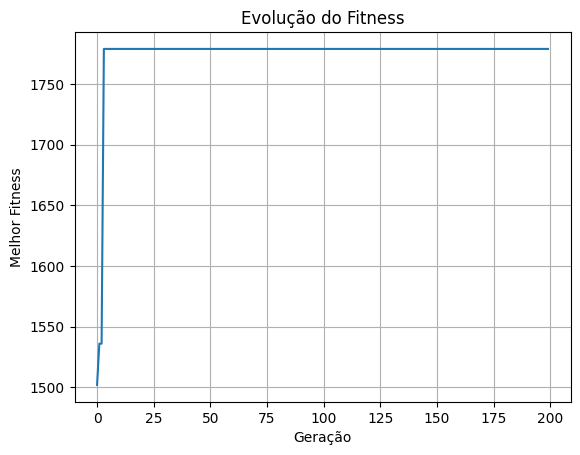


 Avaliação dos Resultados - Dataset 10 itens

Melhor solução encontrada:
[0, 1, 1, 1, 1, 1, 1, 1, 0, 0]
Lucro bruto (sem penalidades): 1840.00
Penalidade aplicada: 1195.00
Lucro final (com penalidade): 645.00
Peso total carregado: 537.00 / 374.00 (limite)
Volume total carregado: 403.00 / 327.00 (limite)
 Excesso de peso!
 Excesso de volume!

 Itens Incluídos na Solução (ordenados por peso):
  item_id  weight  volume  profit    status
3      i4      18      97     461  Incluído
5      i6      58      84     350  Incluído
4      i5      84      26      12  Incluído
6      i7      87      79      49  Incluído
1      i2      93      33     315  Incluído
7      i8      98      37     332  Incluído
2      i3      99      47     321  Incluído

 Itens Excluídos da Solução (ordenados por peso):
  item_id  weight  volume  profit    status
9     i10      48      81      57  Excluído
0      i1      67      74      78  Excluído
8      i9      97      97      94  Excluído

 Espaço restante - Peso: 

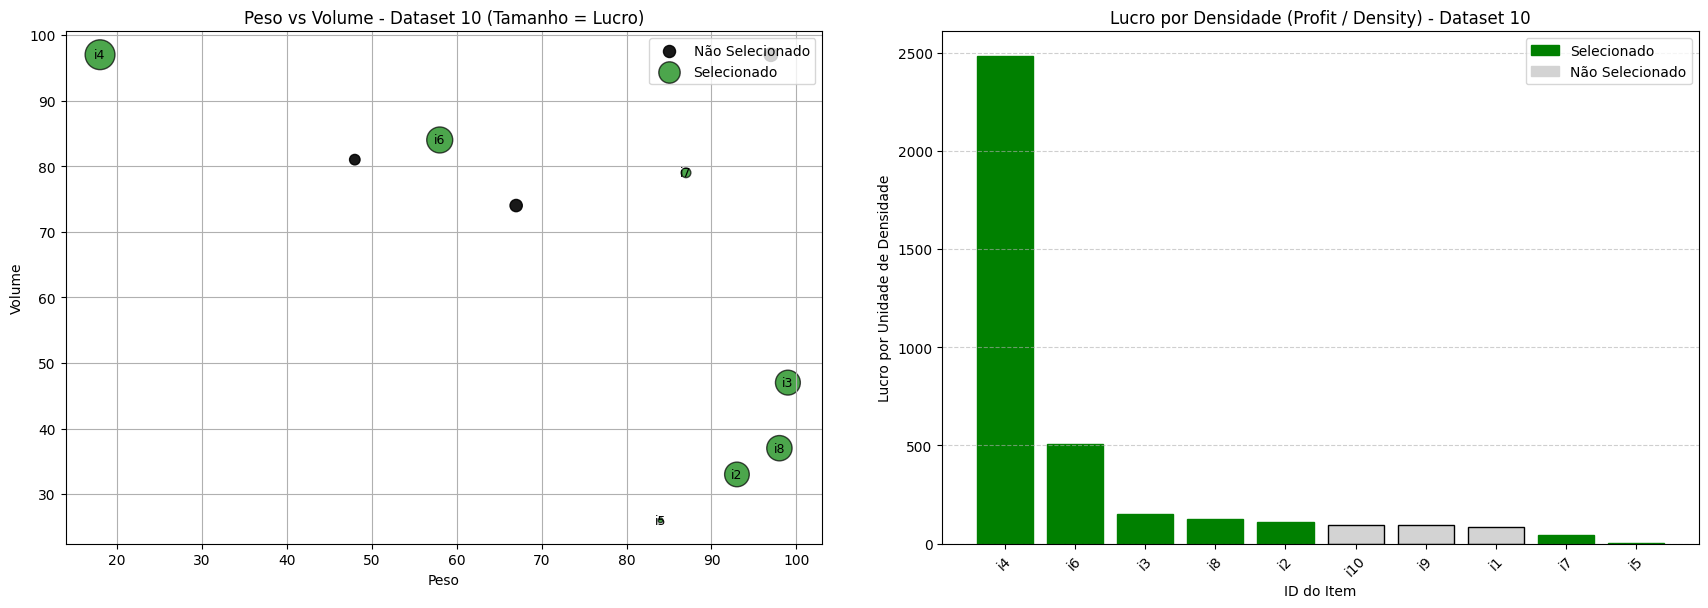

In [23]:
best_individual1, _ = genetic_algorithm(items_10, capacities_10, lambda_volume, lambda_weight)
avaliar_resultado(items_10, capacities_10, best_individual1, lambda_weight, lambda_volume, "Dataset 10 itens")
selected_items_10 = items_10[np.array(best_individual1) == 1].copy()

visualizar_resultados_dataset(items_10, selected_items_10, nome_dataset="Dataset 10")

###Dataset com 20 itens

Geração 1/200 - Melhor Fitness: 3454.541259765625
Geração 2/200 - Melhor Fitness: 3517.927001953125
Geração 3/200 - Melhor Fitness: 3695.27734375
Geração 4/200 - Melhor Fitness: 3719.20361328125
Geração 5/200 - Melhor Fitness: 3785.621337890625
Geração 6/200 - Melhor Fitness: 3927.817626953125
Geração 7/200 - Melhor Fitness: 3927.817626953125
Geração 8/200 - Melhor Fitness: 3951.0
Geração 9/200 - Melhor Fitness: 3951.0
Geração 10/200 - Melhor Fitness: 4013.991943359375
Geração 11/200 - Melhor Fitness: 4013.991943359375
Geração 12/200 - Melhor Fitness: 4013.991943359375
Geração 13/200 - Melhor Fitness: 4013.991943359375
Geração 14/200 - Melhor Fitness: 4013.991943359375
Geração 15/200 - Melhor Fitness: 4013.991943359375
Geração 16/200 - Melhor Fitness: 4013.991943359375
Geração 17/200 - Melhor Fitness: 4013.991943359375
Geração 18/200 - Melhor Fitness: 4013.991943359375
Geração 19/200 - Melhor Fitness: 4013.991943359375
Geração 20/200 - Melhor Fitness: 4013.991943359375
Geração 21/200 -

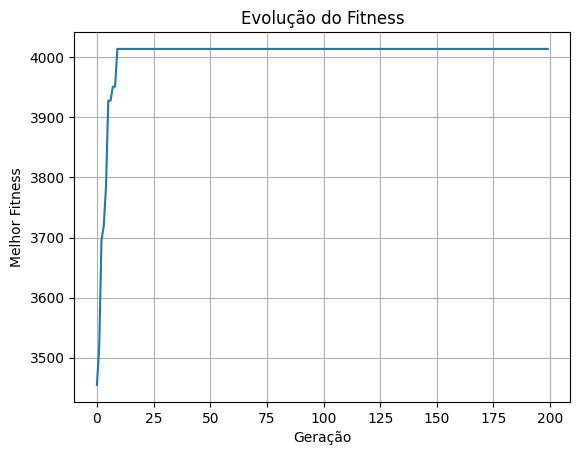


 Avaliação dos Resultados - Dataset 20 itens

Melhor solução encontrada:
[0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0]
Lucro bruto (sem penalidades): 4402.00
Penalidade aplicada: 830.00
Lucro final (com penalidade): 3572.00
Peso total carregado: 745.00 / 616.00 (limite)
Volume total carregado: 449.00 / 412.00 (limite)
 Excesso de peso!
 Excesso de volume!

 Itens Incluídos na Solução (ordenados por peso):
   item_id  weight  volume  profit    status
2       i3       8      78     478  Incluído
9      i10      28      27      61  Incluído
10     i11      35      81     438  Incluído
1       i2      49      23     444  Incluído
5       i6      53      28     278  Incluído
16     i17      65       2     443  Incluído
15     i16      70      72     485  Incluído
17     i18      76      44     352  Incluído
12     i13      77      15     243  Incluído
7       i8      86      53     475  Incluído
11     i12      98       7     383  Incluído
3       i4     100      19     322 

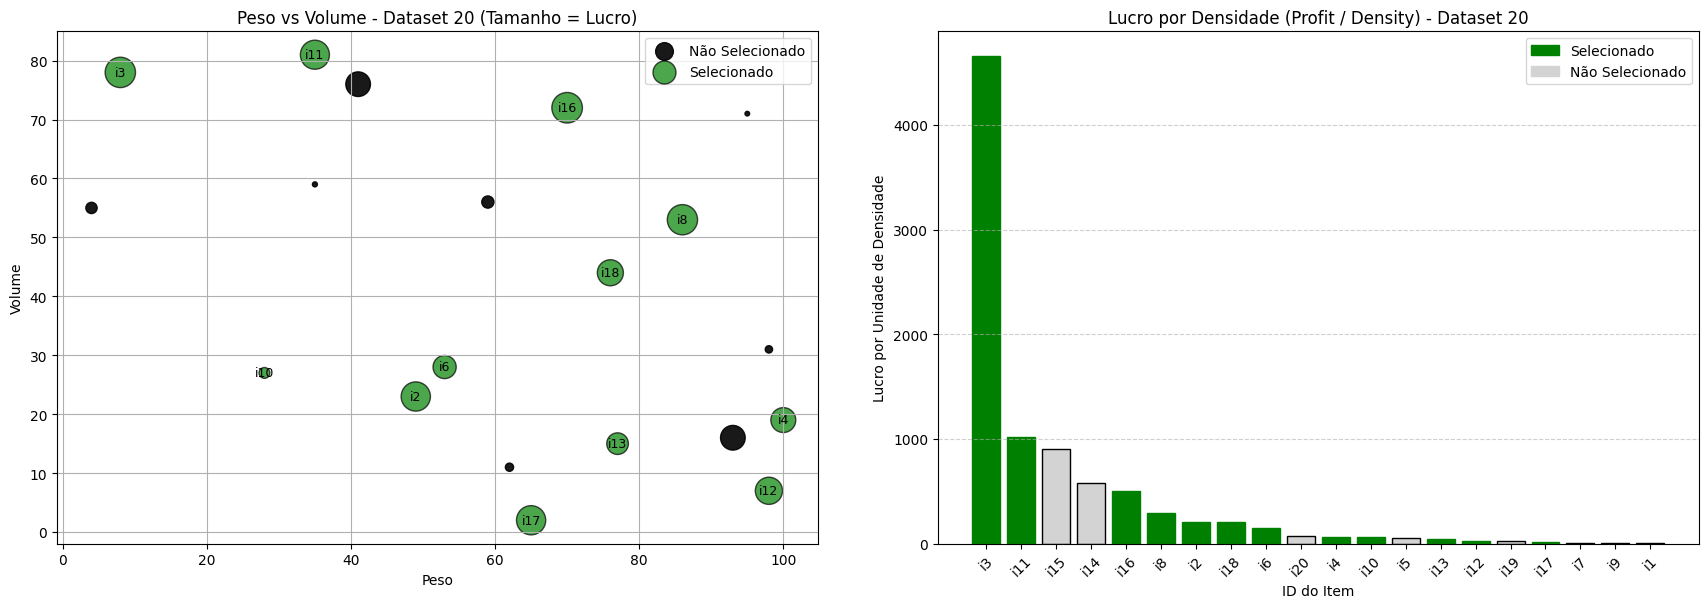

In [24]:
best_individual2, _ = genetic_algorithm(items_20, capacities_20, lambda_volume, lambda_weight)
avaliar_resultado(items_20, capacities_20, best_individual2, lambda_weight, lambda_volume, "Dataset 20 itens")
selected_items_20 = items_20[np.array(best_individual2) == 1].copy()

visualizar_resultados_dataset(items_20, selected_items_20, nome_dataset="Dataset 20")


### Dataset com 40 itens


Geração 1/200 - Melhor Fitness: 6517.00439453125
Geração 2/200 - Melhor Fitness: 6517.00439453125
Geração 3/200 - Melhor Fitness: 6566.0
Geração 4/200 - Melhor Fitness: 6753.333984375
Geração 5/200 - Melhor Fitness: 7395.9521484375
Geração 6/200 - Melhor Fitness: 7465.435546875
Geração 7/200 - Melhor Fitness: 7857.59326171875
Geração 8/200 - Melhor Fitness: 7857.59326171875
Geração 9/200 - Melhor Fitness: 7857.59326171875
Geração 10/200 - Melhor Fitness: 7857.59326171875
Geração 11/200 - Melhor Fitness: 7884.0
Geração 12/200 - Melhor Fitness: 8008.0
Geração 13/200 - Melhor Fitness: 8032.3193359375
Geração 14/200 - Melhor Fitness: 8044.77001953125
Geração 15/200 - Melhor Fitness: 8045.07958984375
Geração 16/200 - Melhor Fitness: 8191.32373046875
Geração 17/200 - Melhor Fitness: 8191.32373046875
Geração 18/200 - Melhor Fitness: 8191.32373046875
Geração 19/200 - Melhor Fitness: 8203.5751953125
Geração 20/200 - Melhor Fitness: 8203.5751953125
Geração 21/200 - Melhor Fitness: 8263.0
Geração

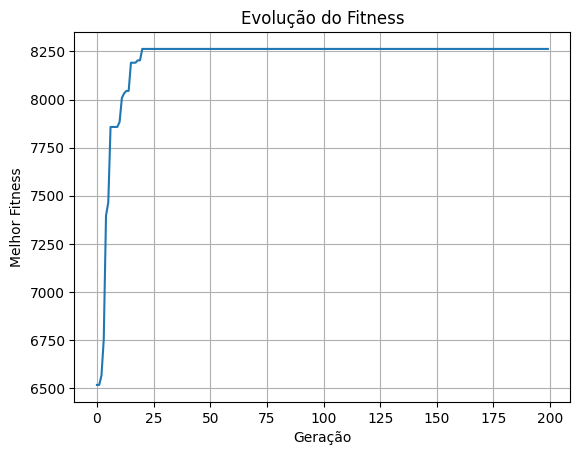


 Avaliação dos Resultados - Dataset 40 itens

Melhor solução encontrada:
[1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0]
Lucro bruto (sem penalidades): 7846.00
Penalidade aplicada: 0.00
Lucro final (com penalidade): 7846.00
Peso total carregado: 804.00 / 883.00 (limite)
Volume total carregado: 1017.00 / 1065.00 (limite)

 Itens Incluídos na Solução (ordenados por peso):
   item_id  weight  volume  profit    status
35     i36       1       8     132  Incluído
38     i39       2       2     417  Incluído
4       i5       4      61     491  Incluído
26     i27       6       7      72  Incluído
8       i9       7      45     248  Incluído
0       i1      12      69     216  Incluído
14     i15      13      29     140  Incluído
29     i30      16      71     420  Incluído
25     i26      17      79     475  Incluído
18     i19      18      97     451  Incluído
1       i2      22      31     450  Incluído
32     i33   

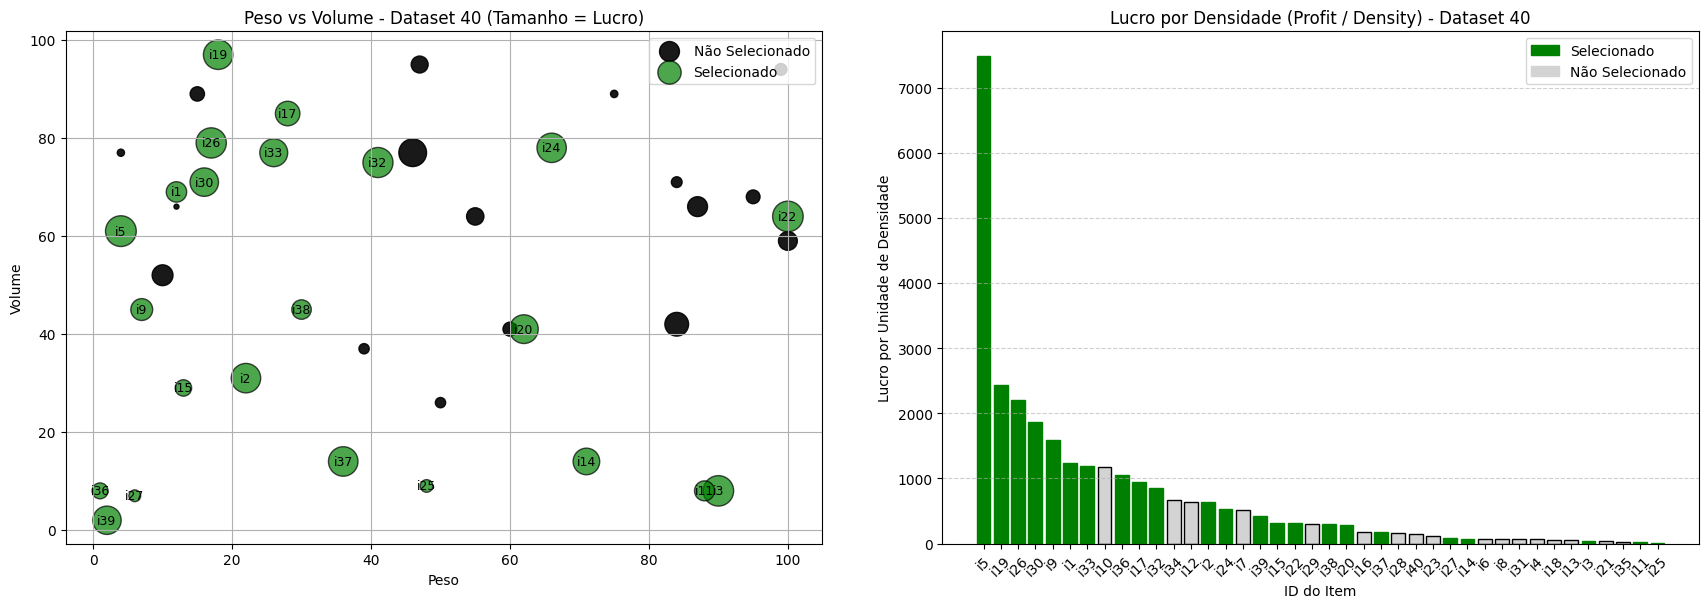

In [25]:
best_individual3, _ = genetic_algorithm(items_df, capacities_df, lambda_volume, lambda_weight)
avaliar_resultado(items_df, capacities_df, best_individual3, lambda_weight, lambda_volume, "Dataset 40 itens")
selected_items_df = items_df[np.array(best_individual3) == 1].copy()

visualizar_resultados_dataset(items_df, selected_items_df, nome_dataset="Dataset 40")

# 7. Análise e Discussão
- As soluções giram muito em cima de ótimos locais, a métrica que avalia o espaço restante constantemente acha falhas na avaliação final do melhor indivíduo da população, encontrando lacunas no transporte que ainda poderiam ter sido preenchidas com itens que foram deixados de fora, tornando-se importante uma pós-avaliação do resultado final do melhor indivíduo
- Outro fator importante de se observar é a métrica que avalia o `profit` pela `density` dos itens presentes, tornando visualizável os itens melhores "disposto" a serem carregados primeiro, já que, numa razão `profit`/`density` alta, significaria um produto cujo o lucro é bem significativo em relação ao peso/espaço ocupado. Sendo assim, fica bastante interessante avaliar o impacto dessa métrica na seleção de itens feita pelo algoritmo, contribuindo bastante para refinar a `fitness_function` ou função de custo do algoritmo.
- Após diversos testes, percebeu-se que para cada tipo de capacidade e quantidade de itens, existem parâmetros diferentes que funcionam de uma melhor forma para aquele tipo de problema, após diferente experimentações, foi-se definido alguns parâmetros que mais aproximaram o algoritmo de encontrar o ótimo global para aquele determinado problema, aqui abaixo estão eles:

Melhores parâmetros encontrados para capacidade_40:

    POP_SIZE = 200

    P_CROSS = 0.9

    P_MUT = 0.01

    MAX_GEN = 100

    ELITISM = True

    TOURNAMENT_K = 3

    lambda_weight = 5

    lambda_volume = 5

Melhores parâmetros encontrados para capacidade_20:

    POP_SIZE = 200

    P_CROSS = 0.9

    P_MUT = 0.005

    MAX_GEN = 100

    ELITISM = True

    TOURNAMENT_K = 5

    lambda_weight = 5

    lambda_volume = 5

Melhores parâmetros encontrados para capacidade_10:

    POP_SIZE = 200

    P_CROSS = 0.8
    
    P_MUT = 0.01
    
    MAX_GEN = 100
    
    ELITISM = True
    
    TOURNAMENT_K = 7
    
    lambda_weight = 5
    
    lambda_volume = 5

# 8. Conclusão
- A aplicação de algoritmos genéticos na resolução do problema da SantosPackLogistics com múltiplas restrições demonstrou ser uma abordagem eficiente, mas que ainda pode ser significativamente aprimorada por meio de análises complementares e ajustes finos nos parâmetros. A avaliação sistemática das soluções revelou que, apesar de frequentemente atingir regiões de ótimos locais, o algoritmo pode deixar de explorar espaços ainda disponíveis no transporte, evidenciando a importância de uma pós-avaliação da solução final. Esse procedimento adicional foi capaz de identificar itens não selecionados que, mesmo compatíveis com as restrições de peso e volume remanescentes, foram ignorados durante a otimização.

- Além disso, a introdução da métrica `profit/density` se mostrou um recurso valioso para interpretar a eficiência dos itens selecionados, pois permite destacar aqueles que oferecem maior retorno financeiro em relação ao espaço ocupado. Essa análise contribui diretamente para o refinamento da função de custo, tornando-a mais sensível à alocação estratégica dos recursos limitados.

- Por fim, os experimentos realizados mostraram que não existe um conjunto único de hiperparâmetros que sirva para todos os cenários. Cada configuração de capacidade (10, 20 e 40) exigiu ajustes específicos nos parâmetros do algoritmo genético para que fosse possível se aproximar do ótimo global. A definição desses parâmetros ideais reforça a importância da experimentação prática e da adaptação ao contexto do problema, evidenciando a necessidade de abordagens customizadas em problemas de otimização com múltiplas restrições.
